# 1.4 Saving Your Chip Design

By the end of this tutorial you will know how to:

1. **Export a design to a Python script** with ``to_python_script()`` — for reproducibility, version control, and CI replay.
2. **Export to GDS** for fabrication, and visually inspect the result.

We start from the full 2-qubit chip built in [tutorial 1.2](./1.1-Quick-start.ipynb). The block below is exactly what ``design.to_python_script()`` produces — a self-contained Python definition you can version-control, share, and replay.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/qiskit-community/qiskit-metal/blob/main/tutorials/1%20Overview/1.4%20Saving%20Your%20Chip%20Design.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/qiskit-community/qiskit-metal/main?labpath=tutorials%2F1%20Overview%2F1.4%20Saving%20Your%20Chip%20Design.ipynb)

> 💡 **Running in Colab or Binder?** Skip the desktop GUI install — the cell below grabs the lite (no-Qt) wheel, and `qm.gui(design)` auto-picks an inline matplotlib viewer with the same API (`gui.rebuild()`, `gui.screenshot()`, `gui.edit_component(...)`) as the desktop `MetalGUI`.

In [1]:
# In Colab / Binder, uncomment to install Quantum Metal (lite, no Qt).
# Locally you should already have it via `pip install quantum-metal` or
# `pip install 'quantum-metal[gui]'` for the desktop GUI.
# !pip install -q quantum-metal

In [2]:
# === Design reproduced from tutorial 1.2 via design.to_python_script() ===
from qiskit_metal import designs, Dict
from qiskit_metal.qlibrary.qubits.transmon_pocket_cl import TransmonPocketCL
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.lumped.cap_3_interdigital import Cap3Interdigital
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond

design = designs.DesignPlanar()
design.overwrite_enabled = True

Q1 = TransmonPocketCL(
    design,
    "Q1",
    options=dict(
        pos_x="0.7mm",
        pos_y="0mm",
        orientation="0",
        pad_gap="30um",
        inductor_width="20um",
        pad_width="425 um",
        pad_height="90um",
        pocket_width="650um",
        pocket_height="650um",
        gds_cell_name="FakeJunction_01",
        make_CL=True,
        cl_gap="6um",
        cl_width="10um",
        cl_length="20um",
        cl_ground_gap="6um",
        cl_pocket_edge="180",
        cl_off_center="50um",
        connection_pads=dict(
            readout=dict(
                loc_W=1,
                loc_H=1,
                pad_gap="15um",
                pad_width="125um",
                pad_height="30um",
                cpw_extend="100um",
                pocket_extent="5um",
                pocket_rise="65um",
            ),
            bus=dict(
                loc_W=-1,
                loc_H=-1,
                pad_gap="15um",
                pad_width="125um",
                pad_height="30um",
                cpw_extend="100um",
                pocket_extent="5um",
                pocket_rise="65um",
            ),
        ),
    ),
    make=True,
)

Q2 = TransmonPocketCL(
    design,
    "Q2",
    options=dict(
        pos_x="-0.7mm",
        pos_y="0mm",
        orientation="180",
        pad_gap="30um",
        inductor_width="20um",
        pad_width="425 um",
        pad_height="90um",
        pocket_width="650um",
        pocket_height="650um",
        gds_cell_name="FakeJunction_01",
        make_CL=True,
        cl_gap="6um",
        cl_width="10um",
        cl_length="20um",
        cl_ground_gap="6um",
        cl_pocket_edge="180",
        cl_off_center="50um",
        connection_pads=dict(
            readout=dict(
                loc_W=1,
                loc_H=1,
                pad_gap="15um",
                pad_width="125um",
                pad_height="30um",
                cpw_extend="100um",
                pocket_extent="5um",
                pocket_rise="65um",
            ),
            bus=dict(
                loc_W=-1,
                loc_H=-1,
                pad_gap="15um",
                pad_width="125um",
                pad_height="30um",
                cpw_extend="100um",
                pocket_extent="5um",
                pocket_rise="65um",
            ),
        ),
    ),
    make=True,
)

Bus_Q1_Q2 = RoutePathfinder(
    design,
    "Bus_Q1_Q2",
    options=dict(
        pin_inputs=dict(
            start_pin=dict(component="Q1", pin="bus"),
            end_pin=dict(component="Q2", pin="bus"),
        ),
        fillet="99um",
        total_length="7mm",
        layer="1",
        lead=dict(start_straight="0mm", end_straight="250um"),
        advanced=dict(avoid_collision="true"),
        step_size="0.25mm",
    ),
)

Cap_Q1 = Cap3Interdigital(
    design,
    "Cap_Q1",
    options=dict(
        layer="1",
        pos_x="2.5mm",
        pos_y="0.25mm",
        orientation="90",
        trace_width="10um",
        finger_length="40um",
    ),
)
Cap_Q2 = Cap3Interdigital(
    design,
    "Cap_Q2",
    options=dict(
        layer="1",
        pos_x="-2.5mm",
        pos_y="-0.25mm",
        orientation="-90",
        trace_width="10um",
        finger_length="40um",
    ),
)

Readout_Q1 = RouteMeander(
    design,
    "Readout_Q1",
    options=dict(
        pin_inputs=dict(
            start_pin=dict(component="Q1", pin="readout"),
            end_pin=dict(component="Cap_Q1", pin="a"),
        ),
        fillet="99um",
        total_length="5mm",
        layer="1",
        lead=dict(start_straight="0.325mm", end_straight="125um"),
        meander=dict(spacing="200um", asymmetry="-50um"),
    ),
)
Readout_Q2 = RouteMeander(
    design,
    "Readout_Q2",
    options=dict(
        pin_inputs=dict(
            start_pin=dict(component="Q2", pin="readout"),
            end_pin=dict(component="Cap_Q2", pin="a"),
        ),
        fillet="99um",
        total_length="6mm",
        layer="1",
        lead=dict(start_straight="0.325mm", end_straight="125um"),
        meander=dict(spacing="200um", asymmetry="-50um"),
    ),
)

for name, px, py, ori in [
    ("Launch_Q1_Read", "3.5mm", "0um", "180"),
    ("Launch_Q2_Read", "-3.5mm", "0um", "0"),
    ("Launch_Q1_CL", "1.35mm", "-2.5mm", "90"),
    ("Launch_Q2_CL", "-1.35mm", "2.5mm", "-90"),
]:
    LaunchpadWirebond(
        design,
        name,
        options=dict(
            layer="1",
            pos_x=px,
            pos_y=py,
            orientation=ori,
            trace_width="cpw_width",
            trace_gap="cpw_gap",
            lead_length="25um",
        ),
    )

for name, src_comp, src_pin, dst_comp, dst_pin, length in [
    ("TL_Q1", "Launch_Q1_Read", "tie", "Cap_Q1", "b", "7mm"),
    ("TL_Q2", "Launch_Q2_Read", "tie", "Cap_Q2", "b", "7mm"),
    ("TL_Q1_CL", "Launch_Q1_CL", "tie", "Q1", "Charge_Line", "7mm"),
    ("TL_Q2_CL", "Launch_Q2_CL", "tie", "Q2", "Charge_Line", "7mm"),
]:
    RoutePathfinder(
        design,
        name,
        options=dict(
            pin_inputs=dict(
                start_pin=dict(component=src_comp, pin=src_pin),
                end_pin=dict(component=dst_comp, pin=dst_pin),
            ),
            fillet="99um",
            total_length=length,
            layer="1",
            lead=dict(start_straight="0mm", end_straight="150um"),
            advanced=dict(avoid_collision="true"),
            step_size="0.25mm",
        ),
    )

print(f"Design ready: {len(design.components)} components")

Design ready: 15 components


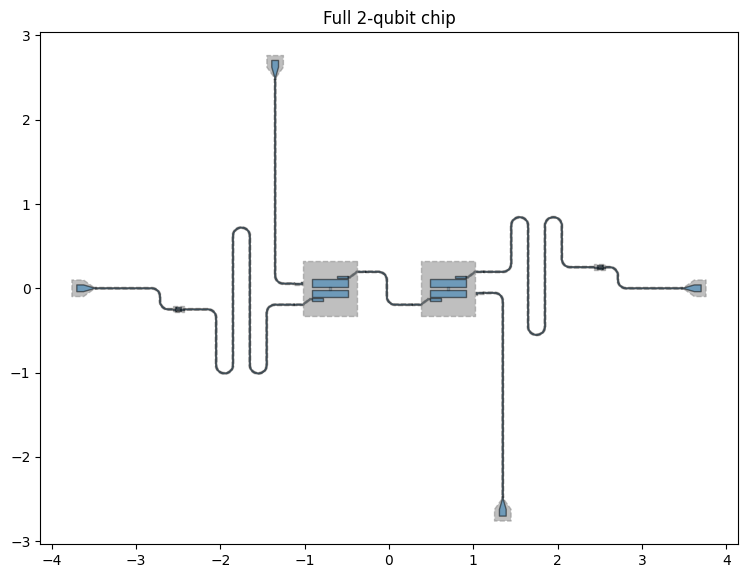

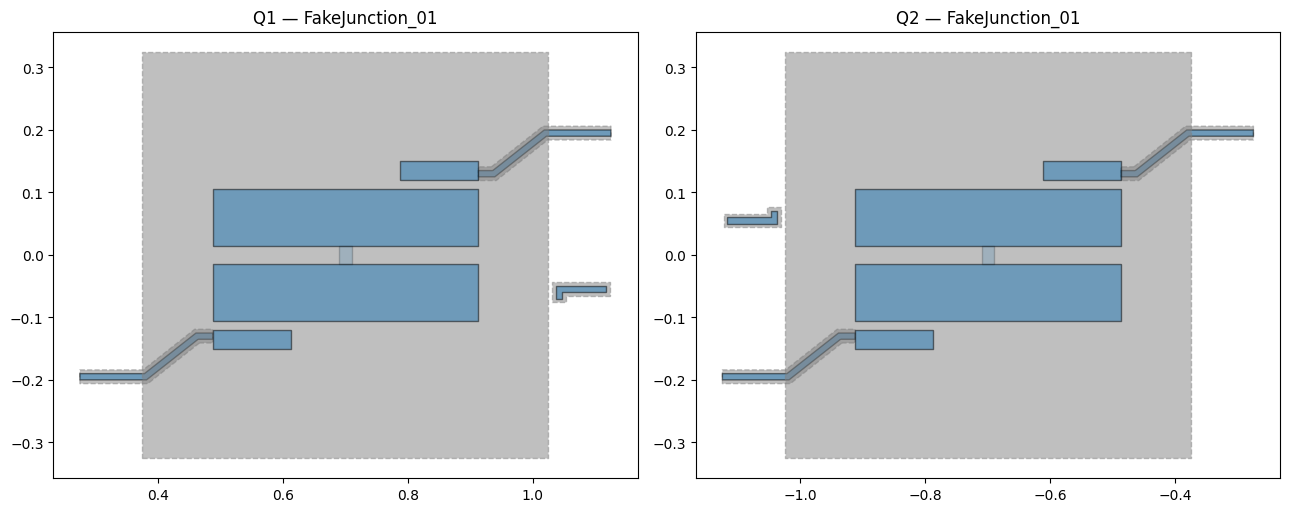

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import qiskit_metal as qm

fig_full = qm.view(design, figsize=(9, 9), title="Full 2-qubit chip")

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
qm.view(design, components=["Q1"], title="Q1 — FakeJunction_01", ax=axes[0])
qm.view(design, components=["Q2"], title="Q2 — FakeJunction_01", ax=axes[1])
plt.tight_layout()
plt.close(fig)

display(fig_full)
display(fig)

In [4]:
design.to_python_script()

"\nfrom qiskit_metal.qlibrary.tlines.meandered import RouteMeander\n\nfrom qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder\n\nfrom qiskit_metal.qlibrary.qubits.transmon_pocket_cl import TransmonPocketCL\n\nfrom qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond\n\nfrom qiskit_metal.qlibrary.lumped.cap_3_interdigital import Cap3Interdigital\n\nfrom qiskit_metal import designs, MetalGUI\n\ndesign = designs.DesignPlanar()\n\ngui = MetalGUI(design)\n\n\n\n            # WARNING\n#options_connection_pads failed to have a value\nQ1 = TransmonPocketCL(\ndesign,\nname='Q1',\noptions={'cl_pocket_edge': '180',\n 'connection_pads': {'bus': {'cpw_extend': '100um',\n                             'cpw_gap': 'cpw_gap',\n                             'cpw_width': 'cpw_width',\n                             'loc_H': -1,\n                             'loc_W': -1,\n                             'pad_cpw_extent': '25um',\n                             'pad_cpw_shift': '5um',

## Saving with `to_python_script()`

`design.to_python_script()` serialises the entire design state — every component, every option, every route — into a self-contained Python script. Running that script recreates the design identically, with no dependency on the original notebook session.

**When to use it:**
- **Version control** — commit the `.py` file alongside your notebook; diffs are readable
- **Sharing** — send the script to a collaborator who can reproduce the exact design
- **Headless / batch** — run the script in CI or a parameter sweep without launching the GUI
- **Long-term archiving** — the script is plain Python, readable years later without notebook tooling

The output prints to the cell below. Copy it into the cell underneath and run it to verify it reproduces your design cleanly.

### Replay the saved script

Copy the output from the cell above into a fresh code cell (or a `.py` file) and run it. It should rebuild the full design without any of the intermediate cells above.

You can also save it directly to a file:

```python
import pathlib

script = design.to_python_script()          # returns the script as a string
pathlib.Path("my_chip_design.py").write_text(script)
print("Saved to my_chip_design.py")
```

Then replay from the command line:

```bash
python my_chip_design.py
```

> **Tip:** the script is deterministic — running it twice produces the same geometry. This makes it safe to use as a fixture in automated tests or as input to a parameter sweep.

## Exporting to GDS

`to_python_script()` captures your design intent; GDS export produces the fabrication mask. The GDS renderer handles junction placement, ground-plane cheesing, and layer assignment.

```python
gds = design.renderers.gds

# Point to a GDS file containing your Josephson junction cells.
# The file can use any unit (µm, nm, mm) — the renderer auto-scales.
gds.options.path_filename = "../resources/Fake_Junctions.GDS"

# Control whether cheese/no-cheese geometry appears in the output.
# {1: False} = process layer 1 but suppress cheese holes from the file.
# Using Dict(main={}) omits the layer entirely and triggers a warning.
gds.options.cheese.view_in_file    = Dict(main={1: False})
gds.options.no_cheese.view_in_file = Dict(main={1: False})

gds.export_to_gds("my_chip.gds")
```

After export, inspect the result:

```python
import gdstk

lib = gdstk.read_gds("my_chip.gds")

# show=True embeds an SVG preview directly in this cell output.
# Increase scale for a larger chip; increase width to fill the cell.
gds.debug_summarize_gds_library(lib, show=True, scale=100, width=900)
```

### Junction units

The qubit components in this design use `gds_cell_name` to name the junction placeholder:

| Qubit | `gds_cell_name` |
|-------|----------------|
| Q1 | `FakeJunction_01` |
| Q2 | `FakeJunction_02` |

These names must match cells inside the GDS file pointed to by `path_filename`. The renderer reads the file's `unit` field and rescales all junction geometry automatically — a junction file in nm, µm, or any other unit will land at the correct physical size. See **1.1 Quick start → Render to GDS** for a full walkthrough including layer options and the debug summary tool.

### What's next

- **1.1 Quick start** — run and visualise this design without the Qt GUI
- **2 From components to chip** — multi-qubit designs, CPW routing, and design variables
- **3 Renderers** — HFSS, Q3D, GDS, and gmsh/Elmer in depth

In [5]:
from qiskit_metal import Dict, open_docs

gds = design.renderers.gds

# Point to a GDS file containing your Josephson junction cells.
# The file can use any unit (µm, nm, mm) — the renderer auto-scales.
gds.options.path_filename = "../resources/Fake_Junctions.GDS"

# Control whether cheese/no-cheese geometry appears in the output.
# {1: False} = process layer 1 but suppress cheese holes from the file.
# Using Dict(main={}) omits the layer entirely and triggers a warning.
gds.options.cheese.view_in_file = Dict(main={1: False})
gds.options.no_cheese.view_in_file = Dict(main={1: False})

gds.export_to_gds("my_chip.gds")

04:57PM 28s WARNING [import_junction_gds_file]: Not able to find file:"../resources/Fake_Junctions.GDS".  Not used to replace junction. Checked directory:"/Users/zlatkominev/CODE_REPOS/quantum_hardware/qiskit-metal/docs/tut/resources".


1

In [6]:
import gdstk

lib = gdstk.read_gds("my_chip.gds")

# show=True embeds an SVG preview directly in this cell output.
# Increase scale for a larger chip; increase width to fill the cell.
gds.debug_summarize_gds_library(lib, show=True, scale=100, width=900)

,Layer,DType,Description,Polygons,Paths
,1,0,metal (boolean result),39 poly,0 paths
,1,10,component polygon input,28 poly,0 paths
,1,11,CPW FlexPath trace,42 poly,0 paths



=== GDS LIBRARY SUMMARY ===
name:      library
unit:      0.001
precision: 1e-09
cells:     4

CELLS:
  - TOP                            geom=True bbox=((-4.5, -3.0), (4.5, 3.0))
  - TOP_main                       geom=True bbox=((-4.5, -3.0), (4.5, 3.0))
  - TOP_main_1                     geom=True bbox=((-4.5, -3.0), (4.5, 3.0))
  - ground_main_1                  geom=True bbox=((-4.5, -3.0), (4.5, 3.0))

LAYER / DATATYPE USAGE:
  layer  dtype   polys   paths
  -----  -----   -----   -----
      1      0      39       0
      1     10      28       0
      1     11      42       0

=== END SUMMARY ===



### GDS layer legend

The renderer writes geometry across several **layer / datatype** pairs.
The layer number matches the `layer` option on each component (default `1`).
The datatype encodes how the geometry was produced:

| Layer | Datatype | Content |
|-------|----------|---------|
| 1 | 0 | **Final metal pattern** — post-boolean result (chip outline, ground plane, qubit pockets merged into a single mask) |
| 1 | 10 | **Component polygons** — individual pad, pocket, and junction-extension-pad outlines before the boolean merge |
| 1 | 11 | **CPW traces** — `FlexPath` geometry for routes, transmission lines, and connectors |
| 53 | 0 | **Junction primary layer** — polygons from the imported junction GDS file (`FakeJunction_01/02`) |
| 54 | 0 | **Junction secondary layer** — second contact layer from the same junction GDS file |

> **Layers 53 and 54 are whatever layers your junction file uses.** If you supply
> your own junction GDS, its layer numbers will appear here instead. Use KLayout's
> layer panel (right-hand side) to toggle each layer on/off and identify them.

The `plot_gds_zoom` panels below colour each `(layer, datatype)` pair distinctly,
making it easy to see where the junction sits relative to the qubit pads.


### Zooming into junction pads in GDS

``debug_summarize_gds_library`` gives a chip-level overview. To inspect individual junctions at fabrication scale, ``gds.plot_gds_zoom`` clips a small window out of the flattened GDS and renders it with matplotlib — no KLayout required.

It works by calling ``top.get_polygons(depth=None)`` to flatten the full cell hierarchy, filtering to a bounding box around your target, then drawing each polygon coloured by ``(layer, datatype)``.

> **Matplotlib backend note:** when ``qm.gui(design)`` returns the desktop ``MetalGUI`` (Qt path), matplotlib's backend is ``Qt6Agg`` — ``plt.subplots()`` then opens a Qt window instead of rendering inline. The ``%matplotlib inline`` cell below resets to the static ``Agg`` backend. With the headless viewer this isn't needed; the inline backend is already active.

In [7]:
# Reset to the static Agg backend so plots render inline.
# Needed because MetalGUI (used above) initialises PySide6 which can
# switch matplotlib to Qt6Agg. See the note in the markdown cell above.
%matplotlib inline

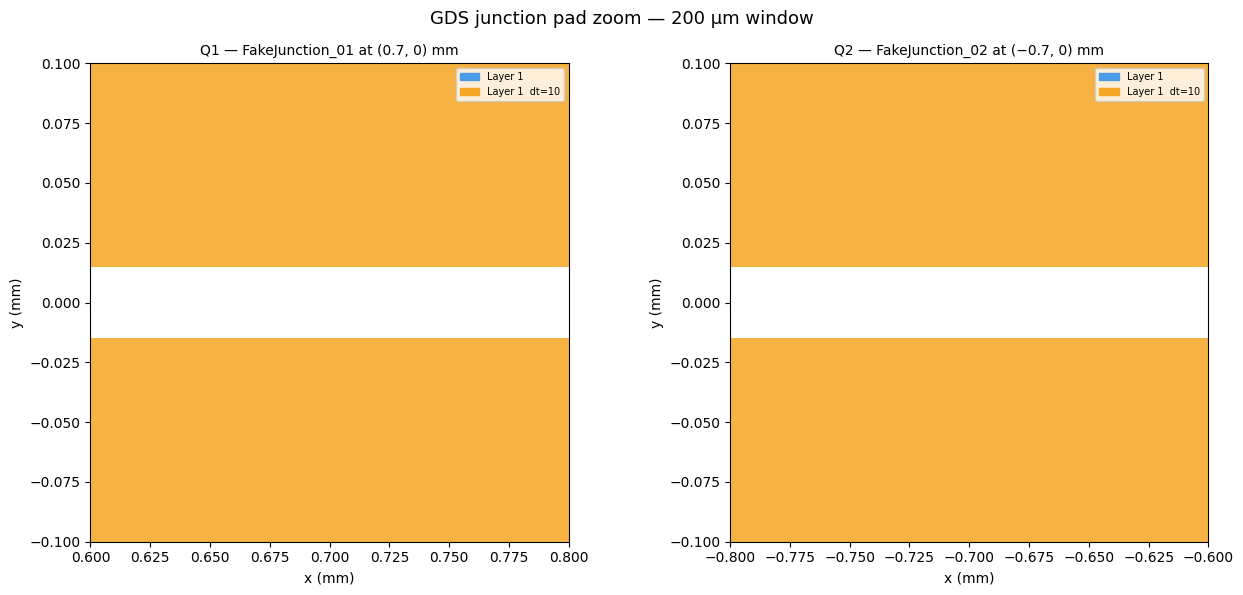

In [8]:
import matplotlib.pyplot as plt

# Zoom into each qubit — 200 µm window centred on the junction.
# Q1 sits at (0.70,  0) mm (orientation   0°) → junction cell rotated  90° → vertical
# Q2 sits at (−0.70, 0) mm (orientation 180°) → junction cell rotated −90° → vertical
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle("GDS junction pad zoom — 200 µm window", fontsize=13)

gds.plot_gds_zoom(
    lib,
    center_mm=(0.70, 0.0),
    span_mm=0.10,
    title="Q1 — FakeJunction_01 at (0.7, 0) mm",
    ax=axes[0],
)
gds.plot_gds_zoom(
    lib,
    center_mm=(-0.70, 0.0),
    span_mm=0.10,
    title="Q2 — FakeJunction_02 at (−0.7, 0) mm",
    ax=axes[1],
)

plt.tight_layout()
# plt.close(fig)
# fig

## Viewing your GDS file

Once you have a `.gds` file, you'll want to inspect it visually — zoom into junction pads, verify layer colours, check that routes don't collide. Several free tools can do this on every platform.

---

### KLayout (recommended)

[KLayout](https://www.klayout.de) is the industry-standard open-source GDS/OASIS viewer and editor. It handles multi-layer designs, has a Python scripting console, and runs on **Windows, macOS, and Linux**.

**Install:**

| Platform | Method |
|----------|---------|
| **macOS** | `brew install --cask klayout` — or download the `.dmg` from [klayout.de/build.html](https://www.klayout.de/build.html) |
| **Windows** | Download the `.exe` installer from [klayout.de/build.html](https://www.klayout.de/build.html) |
| **Linux** | `.rpm` / `.deb` packages available, or `conda install -c conda-forge klayout` |

**Open your file:**

```bash
# From the terminal — opens KLayout with the file loaded
klayout my_chip.gds
```

Or launch KLayout and use **File → Open**.

**Key things to check:**
- **Layer panel** (right side) — toggle layers on/off to isolate metal, junctions, cheese holes
- **Ruler tool** (`R`) — measure distances in design units
- **Zoom to fit** (`F`) — see the full chip at once
- **Zoom into junction pads** — verify physical size matches your design (30 µm × 3 µm for the fake junctions here)

---

### Quick in-notebook preview (no install needed)

You already have `gdstk` and the `debug_summarize_gds_library` tool. For a fast sanity check without leaving Jupyter:

```python
import gdstk
lib = gdstk.read_gds("my_chip.gds")
gds.debug_summarize_gds_library(lib, show=True, scale=100, width=900)
```

This embeds an SVG overview directly in the cell output and saves with the notebook. Good for a quick geometry and layer check; use KLayout for detailed inspection.

---

### Other free viewers

| Tool | Platform | Notes |
|------|----------|-------|
| [gdstk](https://heitzmann.github.io/gdstk/) | Python (all platforms) | Programmatic; `cell.write_svg()` for per-cell previews |
| [Magic VLSI](http://opencircuitdesign.com/magic/) | Linux / macOS | Full DRC + extraction; steeper learning curve |
| [GDS3D](https://github.com/trilomix/GDS3D) | Windows / Linux | 3D visualisation of GDS layers |
